# Instructor Effectiveness Modeling

## 1. Problem Understanding

The objective of this analysis is to estimate instructor effectiveness using learner outcomes, engagement metrics, and learner feedback.

The dataset contains batch-level records, where each row represents a course batch. Since an instructor can teach multiple batches and courses, the batch-level information is first aggregated to the instructor level.

An Instructor Effectiveness Score is then constructed using learning outcomes, engagement, and feedback indicators. Instructors are divided into Low, Medium, and High effectiveness tiers, and classical machine learning models are trained to predict these tiers.

The analysis focuses not only on model performance but also on feature engineering, assumptions, interpretation, limitations, and potential real-world use.


Batch-level Data
       ↓
Data Cleaning & EDA
       ↓
Instructor-level Aggregation
       ↓
Effectiveness Score
       ↓
Low / Medium / High Tiers
       ↓
Train/Test Split
       ↓
Logistic Regression + Random Forest
       ↓
Evaluation
       ↓
Feature Importance
       ↓
Business Interpretation

In [ ]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

In [ ]:
#data loading
df = pd.read_excel("instructor_effectiveness_dataset_2000_rows.xlsx")

print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully!
Rows: 2000
Columns: 12


In [ ]:
#preview
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300,14.226,73.547,0.647,0.775,0.791,0.108,3.766,0.533
1,B_0354,I_119,C_06,0.657,22.871,77.312,0.425,0.495,0.999,0.281,5.000,0.734
2,B_1334,I_050,C_03,0.300,16.088,79.564,0.700,0.978,0.807,0.207,3.517,0.681
3,B_0906,I_024,C_21,0.640,24.261,99.295,0.335,0.847,0.545,0.306,4.208,1.000
4,B_1290,I_001,C_08,0.527,31.082,99.393,0.521,0.917,0.866,0.252,4.426,0.697


In [ ]:
#check columns and data types
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Column names:
['batch_id', 'instructor_id', 'course_id', 'completion_rate', 'avg_score_improvement', 'avg_quiz_score', 'dropout_rate', 'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate', 'avg_feedback_score', 'feedback_response_rate']

Data types:
batch_id                       object
instructor_id                  object
course_id                      object
completion_rate               float64
avg_score_improvement         float64
avg_quiz_score                float64
dropout_rate                  float64
avg_watch_time                float64
assignment_submission_rate    float64
forum_activity_rate           float64
avg_feedback_score            float64
feedback_response_rate        float64
dtype: object


In [ ]:
#checkimg missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values in each column:
batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

Total missing values: 0


In [ ]:
#checking duplicate values 
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:
# Descriptive statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
completion_rate,2000.000,0.603,0.160,0.300,0.489,0.603,0.713,0.980
avg_score_improvement,2000.000,27.036,5.717,6.159,23.125,26.939,30.886,40.000
avg_quiz_score,2000.000,77.956,10.696,40.387,70.898,78.021,85.444,100.000
dropout_rate,2000.000,0.395,0.163,0.020,0.280,0.395,0.511,0.700
avg_watch_time,2000.000,0.777,0.145,0.287,0.675,0.780,0.894,1.000
assignment_submission_rate,2000.000,0.753,0.148,0.251,0.652,0.756,0.856,1.000
forum_activity_rate,2000.000,0.250,0.101,0.000,0.180,0.250,0.319,0.641
avg_feedback_score,2000.000,4.207,0.419,2.640,3.919,4.206,4.503,5.000
feedback_response_rate,2000.000,0.737,0.149,0.260,0.633,0.737,0.846,1.000


In [ ]:
# unique instructors and courses
print("Number of unique batches:", df["batch_id"].nunique())
print("Number of unique instructors:", df["instructor_id"].nunique())
print("Number of unique courses:", df["course_id"].nunique())

Number of unique batches: 2000
Number of unique instructors: 120
Number of unique courses: 25


In [ ]:
# Batches per instructor
batches_per_instructor = df.groupby("instructor_id")["batch_id"].nunique()

print("Batches per instructor:")
print(batches_per_instructor.describe())

Batches per instructor:
count   120.000
mean     16.667
std       4.582
min       7.000
25%      13.750
50%      17.000
75%      19.000
max      31.000
Name: batch_id, dtype: float64


In [10]:
# Check whether percentage/rate variables are within 0–1
rate_columns = [
    "completion_rate",
    "dropout_rate",
    "avg_watch_time",
    "assignment_submission_rate",
    "forum_activity_rate",
    "feedback_response_rate"
]

for col in rate_columns:
    print(
        f"{col}: min={df[col].min():.3f}, "
        f"max={df[col].max():.3f}"
    )

completion_rate: min=0.300, max=0.980
dropout_rate: min=0.020, max=0.700
avg_watch_time: min=0.287, max=1.000
assignment_submission_rate: min=0.251, max=1.000
forum_activity_rate: min=0.000, max=0.641
feedback_response_rate: min=0.260, max=1.000


In [ ]:
# Exploratory Data Analysis (EDA)
# Separate numeric columns
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Numeric columns:")
print(numeric_columns)

Numeric columns:
['completion_rate', 'avg_score_improvement', 'avg_quiz_score', 'dropout_rate', 'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate', 'avg_feedback_score', 'feedback_response_rate']


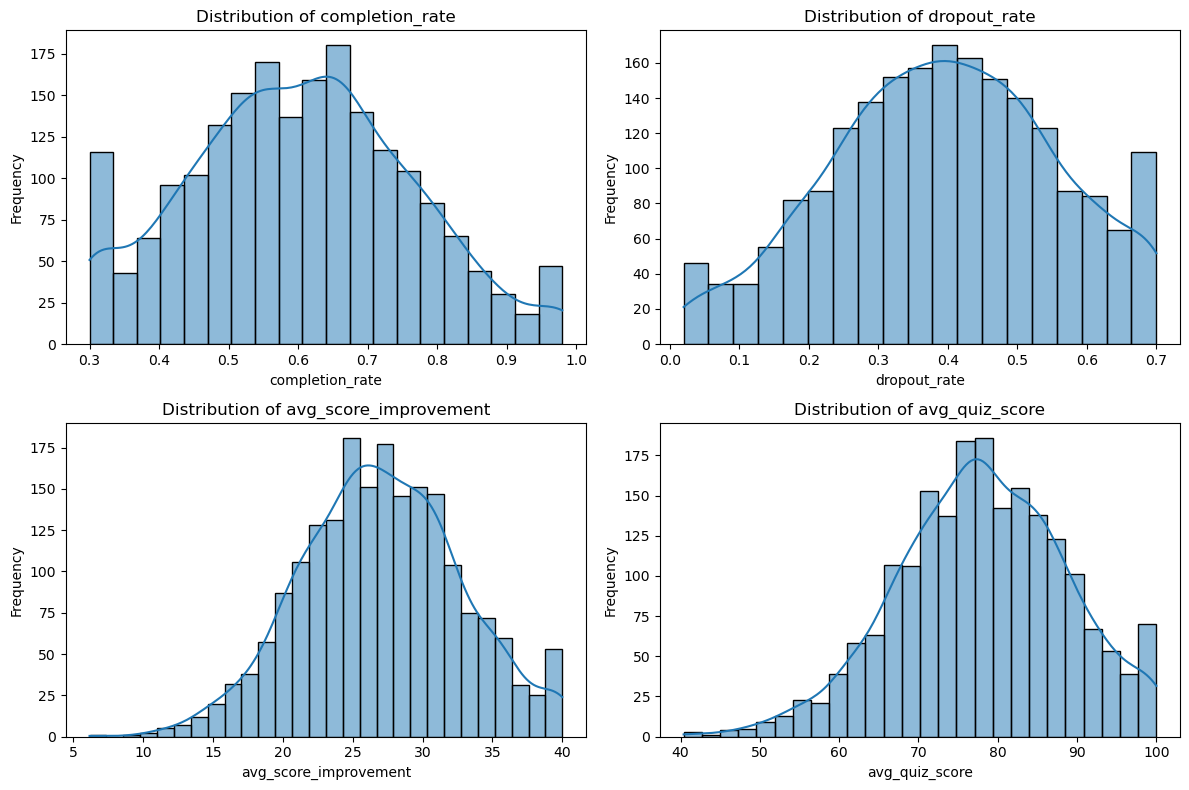

In [ ]:
# Distribution of learner outcome metrics
outcome_columns = [
    "completion_rate",
    "dropout_rate",
    "avg_score_improvement",
    "avg_quiz_score"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), outcome_columns):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

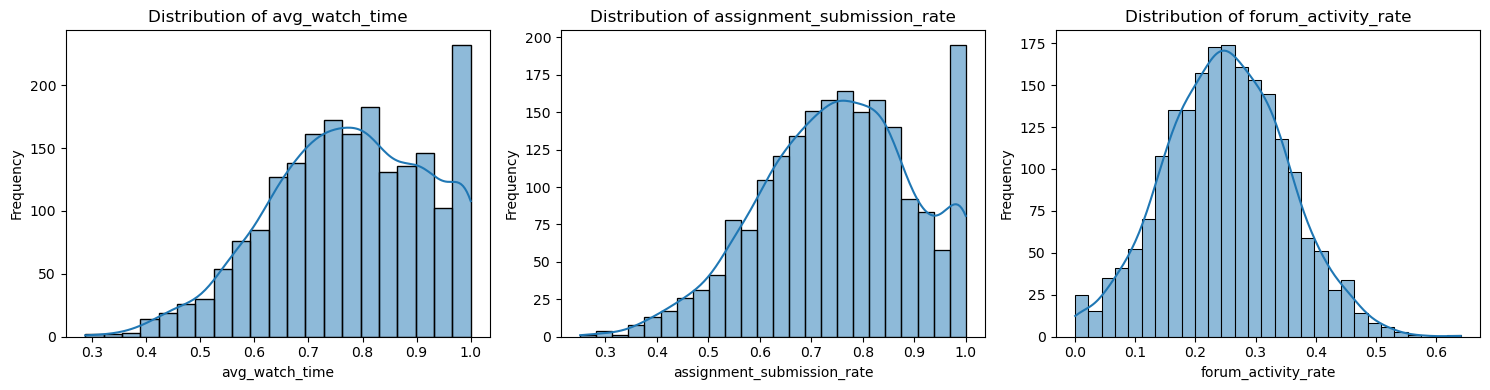

In [ ]:
# Distribution of engagement metrics
engagement_columns = [
    "avg_watch_time",
    "assignment_submission_rate",
    "forum_activity_rate"
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, engagement_columns):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()


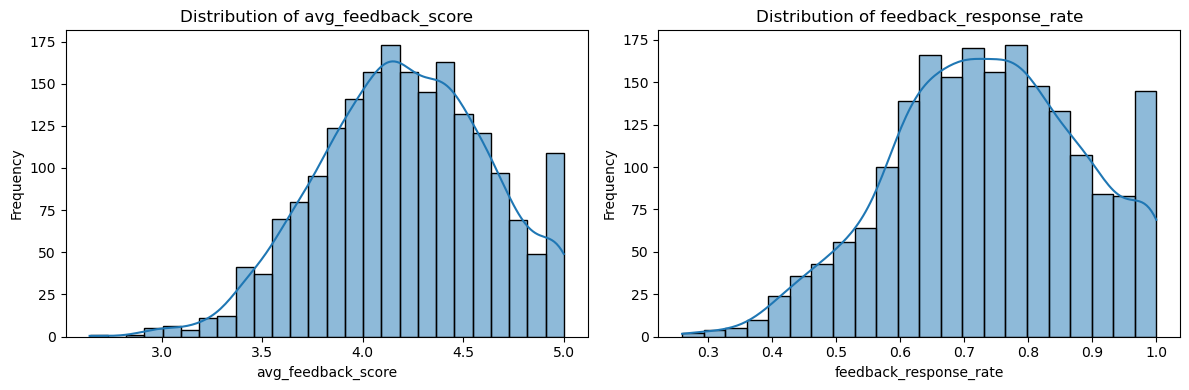

In [ ]:
# Distribution of feedback metrics
feedback_columns = [
    "avg_feedback_score",
    "feedback_response_rate"
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, feedback_columns):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

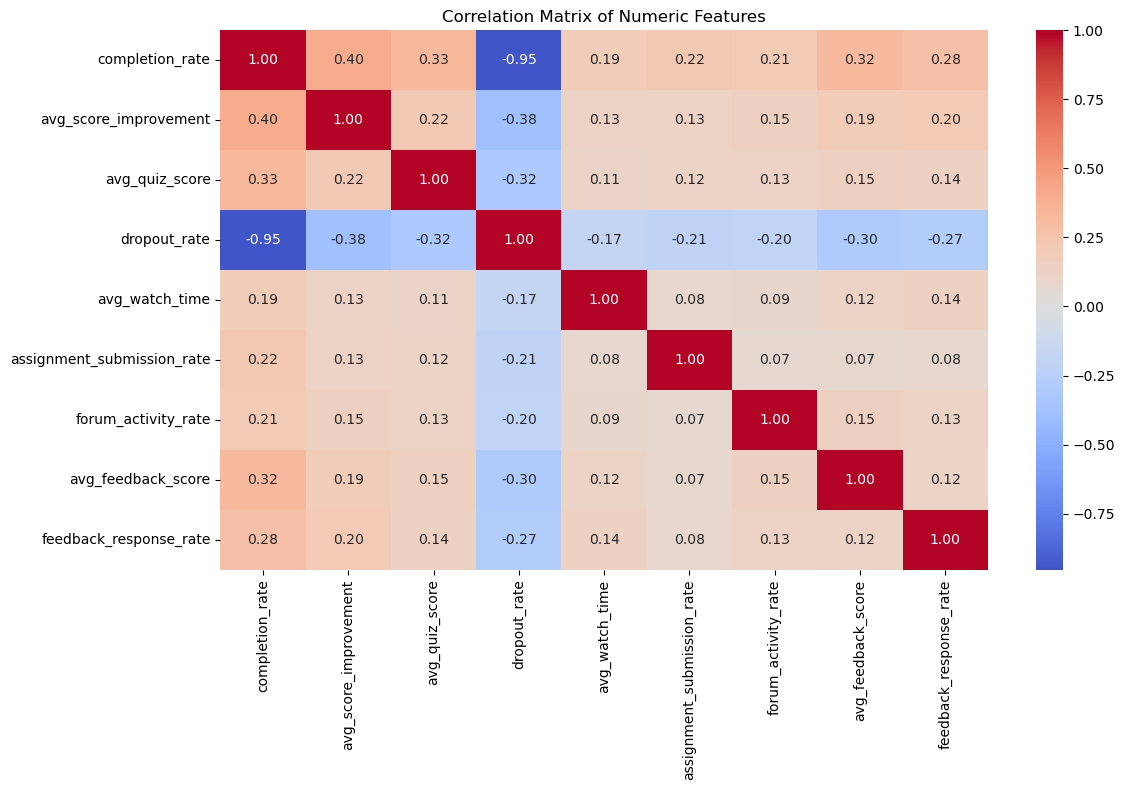

In [ ]:
# Correlation heatmap
plt.figure(figsize=(12, 8))

correlation_matrix = df[numeric_columns].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

In [ ]:
# finding the strongest correlations
corr_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)

print("Strongest feature relationships:")
print(corr_pairs.head(10))

Strongest feature relationships:
completion_rate        dropout_rate                 -0.953
                       avg_score_improvement         0.404
avg_score_improvement  dropout_rate                 -0.381
completion_rate        avg_quiz_score                0.333
                       avg_feedback_score            0.315
avg_quiz_score         dropout_rate                 -0.315
dropout_rate           avg_feedback_score           -0.301
completion_rate        feedback_response_rate        0.280
dropout_rate           feedback_response_rate       -0.274
completion_rate        assignment_submission_rate    0.222
dtype: float64


In [ ]:
# Outlier detection
# IQR-based outlier summary
outlier_summary = []

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers)
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df

,Feature,Q1,Q3,Lower Bound,Upper Bound,Outlier Count
0,completion_rate,0.489,0.713,0.154,1.048,0
1,avg_score_improvement,23.125,30.886,11.483,42.527,6
2,avg_quiz_score,70.898,85.444,49.078,107.264,11
3,dropout_rate,0.280,0.511,-0.067,0.859,0
4,avg_watch_time,0.675,0.894,0.346,1.223,3
5,assignment_submission_rate,0.652,0.856,0.346,1.163,6
6,forum_activity_rate,0.180,0.319,-0.029,0.528,5
7,avg_feedback_score,3.919,4.503,3.042,5.380,11
8,feedback_response_rate,0.633,0.846,0.314,1.165,5


EDA Observations
-The dataset contains 2,000 batch-level records with no missing values or duplicate rows.
-Completion rate and dropout rate show a strong negative relationship, which is expected because higher learner completion generally corresponds to lower dropout.
-Score improvement, quiz performance, engagement metrics, and feedback metrics show meaningful variation across batches.
-Most variables have relatively well-behaved distributions, with only a small number of potential IQR-based outliers.
-Potential outliers were retained because they may represent genuine differences between course batches rather than data-entry errors.
-The strong relationship between completion and dropout should be considered when constructing the instructor effectiveness score to avoid giving excessive weight to closely related measures.

In [ ]:
# batches per instructor
batches_per_instructor = (
    df.groupby("instructor_id")["batch_id"]
    .nunique()
    .reset_index(name="num_batches")
)

batches_per_instructor.head()

,instructor_id,num_batches
0,I_001,25
1,I_002,20
2,I_003,18
3,I_004,17
4,I_005,19


In [ ]:
# Instructor-level aggregation
performance_columns = [
    "completion_rate",
    "dropout_rate",
    "avg_score_improvement",
    "avg_quiz_score",
    "avg_watch_time",
    "assignment_submission_rate",
    "forum_activity_rate",
    "avg_feedback_score",
    "feedback_response_rate"
]

instructor_df = (
    df.groupby("instructor_id")[performance_columns]
    .mean()
    .reset_index()
)

instructor_df.head()

,instructor_id,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,I_001,0.544,0.471,26.641,78.900,0.767,0.727,0.241,4.218,0.695
1,I_002,0.731,0.247,30.166,81.737,0.837,0.774,0.290,4.343,0.784
2,I_003,0.768,0.235,29.978,81.591,0.818,0.780,0.296,4.450,0.812
3,I_004,0.458,0.547,22.912,77.680,0.793,0.758,0.226,4.076,0.721
4,I_005,0.860,0.146,32.589,85.828,0.847,0.877,0.334,4.203,0.784


In [ ]:
# Add number of batches taught
instructor_df = instructor_df.merge(
    batches_per_instructor,
    on="instructor_id",
    how="left"
)

instructor_df.head()

,instructor_id,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,num_batches
0,I_001,0.544,0.471,26.641,78.900,0.767,0.727,0.241,4.218,0.695,25
1,I_002,0.731,0.247,30.166,81.737,0.837,0.774,0.290,4.343,0.784,20
2,I_003,0.768,0.235,29.978,81.591,0.818,0.780,0.296,4.450,0.812,18
3,I_004,0.458,0.547,22.912,77.680,0.793,0.758,0.226,4.076,0.721,17
4,I_005,0.860,0.146,32.589,85.828,0.847,0.877,0.334,4.203,0.784,19


In [ ]:
# Verify aggregation
print("Number of instructors:", instructor_df["instructor_id"].nunique())
print("Instructor-level rows:", len(instructor_df))

print("\nBatches per instructor:")
print(instructor_df["num_batches"].describe())

Number of instructors: 120
Instructor-level rows: 120

Batches per instructor:
count   120.000
mean     16.667
std       4.582
min       7.000
25%      13.750
50%      17.000
75%      19.000
max      31.000
Name: num_batches, dtype: float64


Aggregation Approach

Since each instructor can teach multiple batches, batch-level metrics were aggregated to the instructor level using the mean. The mean represents the typical performance of an instructor across the batches they taught.

The number of batches taught was also retained as an additional feature. This helps provide context about the amount of data available for each instructor.

Instructors with fewer batches were not removed because the assignment does not specify a minimum batch threshold. However, their effectiveness estimates may be less stable than those of instructors with many batches. This limitation is considered when interpreting the results.

In [ ]:
# Creat ingthe Instructor Effectiveness Score
# Convert metrics to 0–100
score_df = instructor_df.copy()

# Positive metrics: higher is better
positive_rate_columns = [
    "completion_rate",
    "avg_watch_time",
    "assignment_submission_rate",
    "forum_activity_rate",
    "feedback_response_rate"
]

for col in positive_rate_columns:
    score_df[col + "_score"] = score_df[col] * 100

# Feedback score: convert 1–5 to 0–100
score_df["feedback_score"] = (
    score_df["avg_feedback_score"] / 5
) * 100

# Quiz score is already on a 0–100 scale
score_df["quiz_score"] = score_df["avg_quiz_score"]

# Score improvement: normalize relative to observed range
score_df["improvement_score"] = (
    (score_df["avg_score_improvement"] -
     score_df["avg_score_improvement"].min()) /
    (score_df["avg_score_improvement"].max() -
     score_df["avg_score_improvement"].min())
) * 100

# Dropout is negative, so convert it into a positive "retention" score
score_df["retention_score"] = (
    1 - score_df["dropout_rate"]
) * 100

In [ ]:
# Calculate the three components
score_df["learning_outcome_score"] = (
    0.30 * score_df["completion_rate_score"] +
    0.20 * score_df["retention_score"] +
    0.25 * score_df["improvement_score"] +
    0.25 * score_df["quiz_score"]
)

score_df["engagement_score"] = (
    0.40 * score_df["avg_watch_time_score"] +
    0.35 * score_df["assignment_submission_rate_score"] +
    0.25 * score_df["forum_activity_rate_score"]
)

score_df["feedback_score_component"] = (
    0.70 * score_df["feedback_score"] +
    0.30 * score_df["feedback_response_rate_score"]
)

In [ ]:
# Final effectiveness score
score_df["effectiveness_score"] = (
    0.50 * score_df["learning_outcome_score"] +
    0.30 * score_df["engagement_score"] +
    0.20 * score_df["feedback_score_component"]
)

score_df[
    ["instructor_id", "learning_outcome_score",
     "engagement_score", "feedback_score_component",
     "effectiveness_score"]
].head()

,instructor_id,learning_outcome_score,engagement_score,feedback_score_component,effectiveness_score
0,I_001,58.845,62.116,79.894,64.036
1,I_002,75.117,67.840,84.332,74.777
2,I_003,76.162,67.429,86.664,75.643
3,I_004,48.636,63.923,78.714,59.237
4,I_005,85.805,72.912,82.361,81.248


In [ ]:
# Creating Effectiveness Tiers
# Inspecting the effectiveness score
score_df["effectiveness_score"].describe()

count   120.000
mean     66.532
std       8.043
min      46.482
25%      61.412
50%      66.655
75%      71.030
max      87.536
Name: effectiveness_score, dtype: float64

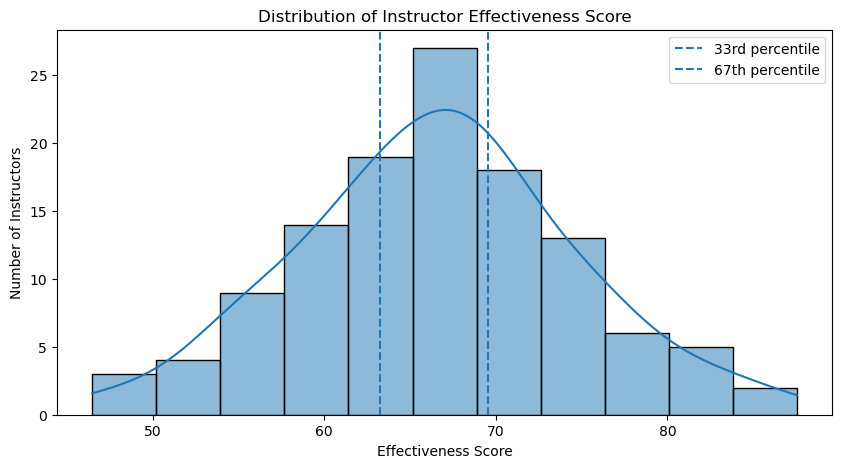

In [ ]:
# Effectiveness score distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    score_df["effectiveness_score"],
    kde=True
)

plt.axvline(
    score_df["effectiveness_score"].quantile(0.33),
    linestyle="--",
    label="33rd percentile"
)

plt.axvline(
    score_df["effectiveness_score"].quantile(0.67),
    linestyle="--",
    label="67th percentile"
)

plt.title("Distribution of Instructor Effectiveness Score")
plt.xlabel("Effectiveness Score")
plt.ylabel("Number of Instructors")
plt.legend()
plt.show()

In [ ]:
# Creating the tiers
score_df["effectiveness_tier"] = pd.qcut(
    score_df["effectiveness_score"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [ ]:
# Checking tier distribution
tier_counts = score_df["effectiveness_tier"].value_counts().sort_index()

print(tier_counts)

print("\nPercentage distribution:")
print(
    (score_df["effectiveness_tier"]
     .value_counts(normalize=True)
     .sort_index() * 100)
)

effectiveness_tier
Low       40
Medium    40
High      40
Name: count, dtype: int64

Percentage distribution:
effectiveness_tier
Low      33.333
Medium   33.333
High     33.333
Name: proportion, dtype: float64


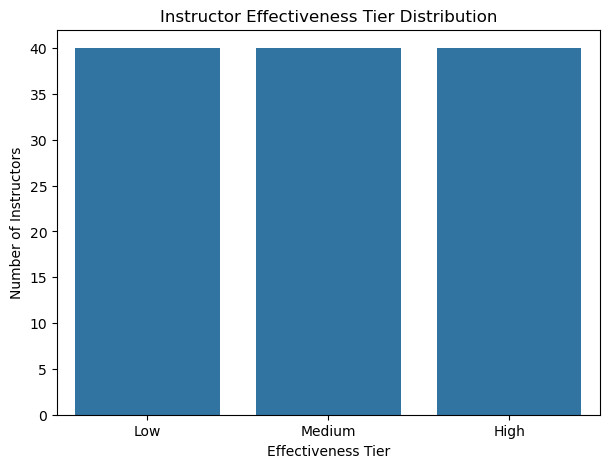

In [ ]:
# Visualize tiers
plt.figure(figsize=(7, 5))

sns.countplot(
    data=score_df,
    x="effectiveness_tier"
)

plt.title("Instructor Effectiveness Tier Distribution")
plt.xlabel("Effectiveness Tier")
plt.ylabel("Number of Instructors")
plt.show()

In [ ]:
# Preparing Data for Machine Learning
# Creating ML dataset
ml_features = [
    "completion_rate",
    "dropout_rate",
    "avg_score_improvement",
    "avg_quiz_score",
    "avg_watch_time",
    "assignment_submission_rate",
    "forum_activity_rate",
    "avg_feedback_score",
    "feedback_response_rate",
    "num_batches"
]

X = score_df[ml_features]
y = score_df["effectiveness_tier"]

In [ ]:
# Checking the ML data
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (120, 10)
Target shape: (120,)

Target distribution:
effectiveness_tier
Low       40
Medium    40
High      40
Name: count, dtype: int64


In [ ]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 96
Testing samples: 24


In [ ]:
# Logistic Regression Baseline
#  Train Logistic Regression

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)

In [ ]:
# Evaluate Logistic Regression
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(
    y_test, y_pred_logistic, average="weighted"
)
logistic_recall = recall_score(
    y_test, y_pred_logistic, average="weighted"
)
logistic_f1 = f1_score(
    y_test, y_pred_logistic, average="weighted"
)

print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy : {logistic_accuracy:.3f}")
print(f"Precision: {logistic_precision:.3f}")
print(f"Recall   : {logistic_recall:.3f}")
print(f"F1 Score : {logistic_f1:.3f}")

Logistic Regression Results
---------------------------
Accuracy : 0.875
Precision: 0.909
Recall   : 0.875
F1 Score : 0.878


In [ ]:
# Detailed classification report
print(classification_report(
    y_test,
    y_pred_logistic
))

              precision    recall  f1-score   support

        High       1.00      0.88      0.93         8
         Low       1.00      0.75      0.86         8
      Medium       0.73      1.00      0.84         8

    accuracy                           0.88        24
   macro avg       0.91      0.88      0.88        24
weighted avg       0.91      0.88      0.88        24



In [ ]:
# Random Forest
# Train Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=None,
    min_samples_split=2,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [ ]:
# Evaluate Random Forest
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(
    y_test, y_pred_rf, average="weighted"
)
rf_recall = recall_score(
    y_test, y_pred_rf, average="weighted"
)
rf_f1 = f1_score(
    y_test, y_pred_rf, average="weighted"
)

print("Random Forest Results")
print("---------------------")
print(f"Accuracy : {rf_accuracy:.3f}")
print(f"Precision: {rf_precision:.3f}")
print(f"Recall   : {rf_recall:.3f}")
print(f"F1 Score : {rf_f1:.3f}")

Random Forest Results
---------------------
Accuracy : 0.958
Precision: 0.963
Recall   : 0.958
F1 Score : 0.958


In [ ]:
# Detailed classification report
print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

        High       1.00      0.88      0.93         8
         Low       1.00      1.00      1.00         8
      Medium       0.89      1.00      0.94         8

    accuracy                           0.96        24
   macro avg       0.96      0.96      0.96        24
weighted avg       0.96      0.96      0.96        24



In [ ]:

# Compare the Models
# Model comparison
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ],
    "Precision": [
        logistic_precision,
        rf_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall
    ],
    "F1 Score": [
        logistic_f1,
        rf_f1
    ]
})

model_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.875,0.909,0.875,0.878
1,Random Forest,0.958,0.963,0.958,0.958


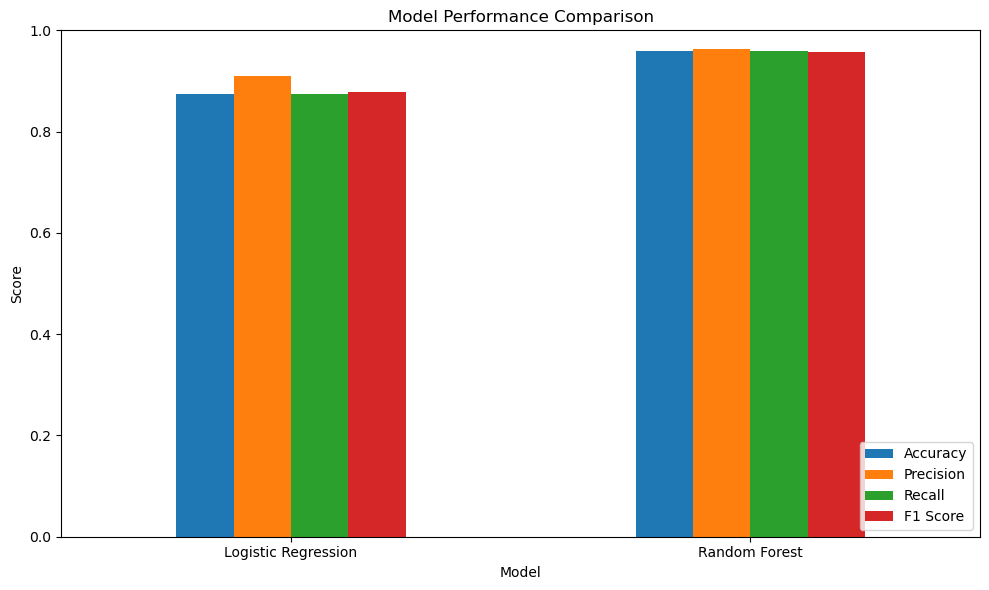

In [ ]:
# Visual comparison
model_results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

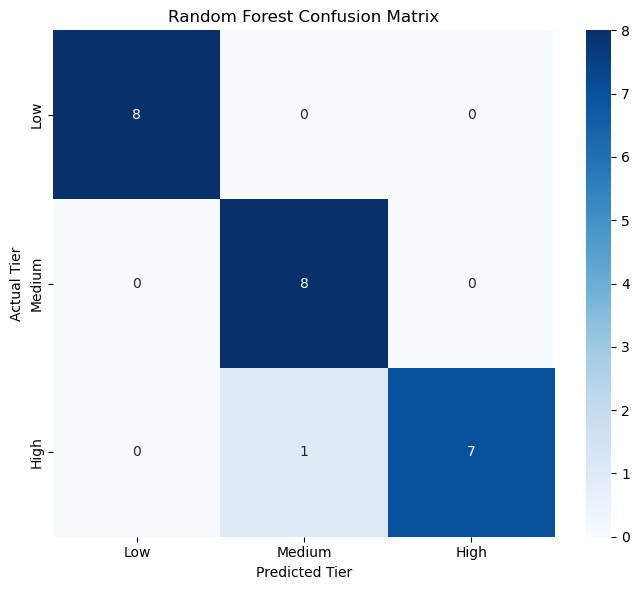

In [ ]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=["Low", "Medium", "High"]
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Tier")
plt.ylabel("Actual Tier")
plt.tight_layout()
plt.show()

In [ ]:
# Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,avg_score_improvement,0.262
0,completion_rate,0.203
8,feedback_response_rate,0.156
1,dropout_rate,0.150
3,avg_quiz_score,0.066
5,assignment_submission_rate,0.045
7,avg_feedback_score,0.039
4,avg_watch_time,0.037
6,forum_activity_rate,0.032
9,num_batches,0.010


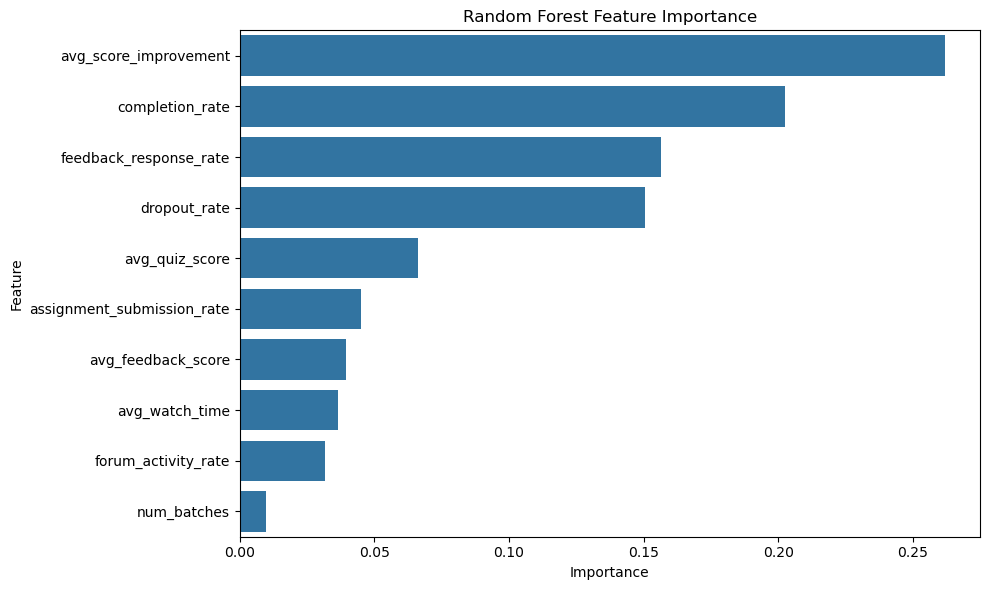

In [ ]:
# Plot feature importance
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
# Save the final instructor-level dataset
final_instructor_data = score_df.copy()

final_instructor_data[
    [
        "instructor_id",
        "num_batches",
        "effectiveness_score",
        "effectiveness_tier"
    ]
].sort_values(
    "effectiveness_score",
    ascending=False
).head(10)

,instructor_id,num_batches,effectiveness_score,effectiveness_tier
9,I_010,13,87.536,High
36,I_037,15,85.497,High
104,I_105,16,83.172,High
17,I_018,14,82.911,High
90,I_091,8,82.491,High
4,I_005,19,81.248,High
117,I_118,19,80.083,High
24,I_025,19,78.930,High
14,I_015,17,77.936,High
50,I_051,26,77.793,High


## Model Results and Interpretation

Two classification models were evaluated: Logistic Regression as a baseline model and Random Forest as the primary model.

Random Forest achieved an accuracy of **95.8%**, compared with **87.5%** for Logistic Regression. Random Forest also achieved higher weighted precision (96.3%), recall (95.8%), and F1 score (95.8%). This indicates that Random Forest provided better overall classification performance for the three instructor effectiveness tiers.

The confusion matrix shows that the Random Forest correctly classified all 8 Low-effectiveness and all 8 Medium-effectiveness instructors in the test set. For the High-effectiveness class, 7 out of 8 instructors were correctly classified, while one High instructor was classified as Medium. There were no Low-to-High or High-to-Low classification errors.

The stronger performance of Random Forest compared with Logistic Regression suggests that the relationship between the instructor-level metrics and effectiveness tiers may include nonlinear patterns that are better captured by a tree-based model.

### Feature Importance

The most influential feature was **average score improvement**, followed by **completion rate**, **feedback response rate**, and **dropout rate**. Average score improvement is particularly meaningful because it directly measures learner progress between assessments. Completion rate also provides an important indicator of learner success and persistence.

Feedback response rate was also relatively influential. However, this should not be interpreted as evidence that higher feedback participation directly causes better instructor performance. Feedback response may be influenced by learner engagement or other factors.

The `num_batches` feature had very low importance, suggesting that the number of batches taught contributed relatively little to the model's predictions compared with learner outcome and engagement measures.

Feature importance indicates predictive usefulness rather than causation. Therefore, these results should be interpreted as associations within this dataset rather than causal relationships.


## 1. Which features most influenced instructor effectiveness, and why?

Based on the Random Forest feature importance results, **average score improvement** was the most influential feature, followed by **completion rate**, **feedback response rate**, and **dropout rate**.

Average score improvement is an important indicator because it measures learner progress between pre- and post-assessments. Completion rate reflects whether learners successfully remain in and finish the course. Dropout rate provides the opposite signal, where higher dropout is associated with lower effectiveness.

Feedback response rate was also relatively influential, although it should be interpreted carefully because it may reflect learner engagement and willingness to provide feedback rather than instructor quality alone.

These feature importance results indicate predictive usefulness, not causation.


## 2. Which variables could be misleading or confounded?

Several variables may be influenced by factors other than instructor effectiveness.

**Feedback response rate** may depend on learner motivation, course design, or how willing learners are to provide feedback. Therefore, a high response rate does not necessarily mean that the instructor is more effective.

**Forum activity rate** can also be affected by the course subject, learner preferences, or whether the course naturally encourages discussion.

**Completion rate and dropout rate** may be influenced by learner characteristics, course difficulty, workload, or external circumstances. The strong negative correlation between completion and dropout also means that these two variables contain overlapping information.

**Number of batches taught** may reflect instructor experience, but it can also reflect organizational staffing decisions rather than teaching quality.

Therefore, these variables should be interpreted as indicators associated with instructor effectiveness rather than direct measures of instructor quality.


## 3. How could this model fail in real-world usage?

The model could fail if the data distribution changes significantly from the dataset used for training. For example, instructors may teach different types of courses, learner populations may change, or the platform may introduce new teaching methods.

The model could also produce misleading results when an instructor has only a small number of batches. Their average performance may not be stable enough to represent their long-term effectiveness.

Another important limitation is that the effectiveness tiers in this analysis were created from the same performance variables that were later used as model features. Therefore, the high model accuracy primarily indicates that the Random Forest can reproduce the defined scoring framework. It does not independently prove that the model can measure true instructor effectiveness.

The model may also reflect confounding factors such as course difficulty, learner motivation, and differences between learner groups.


## 4. What additional data would you want to improve this analysis?

Additional information could make the analysis more reliable.

Useful data would include:

* Learner pre-course and post-course assessment scores at the individual level
* Course difficulty and subject area
* Learner demographics and prior knowledge, where appropriate and ethically permissible
* Instructor experience and teaching experience
* Class size for each batch
* Attendance and session participation
* Individual learner assignment and assessment history
* Qualitative learner feedback
* Instructor teaching methods and content delivery information
* Historical instructor performance across multiple time periods

Individual learner-level data would be particularly useful because batch averages can hide differences between learners within the same batch.


## 5. Should this model be used for instructor performance evaluation? Why or why not?

The model should **not be used as the sole basis for instructor performance evaluation**.

The model can be useful as a decision-support tool for identifying patterns, highlighting instructors who may need additional support, and helping an EdTech platform understand factors associated with learner outcomes.

However, the model is based on a manually defined effectiveness score and the available variables may contain confounding factors. The model also does not capture all aspects of teaching quality, such as teaching style, content quality, mentoring ability, or individual learner circumstances.

Therefore, the model should be used alongside human review and additional qualitative and quantitative information rather than as an automated system for hiring, firing, promotion, or other high-impact decisions.


## Conclusion

This analysis developed a framework for estimating instructor effectiveness using learner outcomes, engagement, and feedback data.

Batch-level information was aggregated to the instructor level, and an Instructor Effectiveness Score was created using learning outcomes, engagement, and learner feedback. The score was then divided into Low, Medium, and High effectiveness tiers using percentile-based thresholds.

Two machine learning models were evaluated. Logistic Regression achieved an accuracy of **87.5%**, while Random Forest achieved **95.8% accuracy**, with a weighted F1 score of **95.8%**. The Random Forest therefore provided the stronger predictive performance on the test set.

Average score improvement was the most influential feature, followed by completion rate, feedback response rate, and dropout rate.

Despite the strong predictive performance, the model should not be interpreted as a definitive measure of teaching quality. The effectiveness tiers were derived from the same variables used as model inputs, and several variables may be affected by confounding factors such as learner motivation, course difficulty, and engagement. Therefore, the model is best viewed as an analytical and decision-support tool rather than an automated instructor evaluation system.

Overall, the analysis demonstrates how structured feature engineering, aggregation, classical machine learning, and careful interpretation can be used to analyze instructor effectiveness in an EdTech setting.
